# 🏷️ Урок 4: Кодирование категориальных признаков

## Зачем кодировать категории?

ML-модели понимают только **числа**. Если у вас есть признак «город» со значениями «Москва», «СПб», «Казань» — модель не сможет с ним работать.

### 🍎 Житейская аналогия

Представьте, что вы заполняете анкету на сайте:
- Пол: М/Ж → это уже кодировка!
- Город: выпадающий список с кодами
- Образование: 1=Школа, 2=Бакалавр, 3=Магистр

**Кодирование — это перевод человеческого языка на язык машин!**

## 🏢 Применение в бизнесе

| Категория | Метод кодирования | Бизнес-применение |
|-----------|-------------------|-------------------|
| **Пол, Да/Нет** | Label Encoding | Кредитный скоринг, отток |
| **Город, Страна** | One-Hot Encoding | Сегментация клиентов |
| **Образование** | Ordinal Encoding | Прогноз зарплаты |
| **Редкие категории** | Target Encoding | Рекомендательные системы |

**Важно**: Неправильный выбор кодировки может ухудшить модель на 10-20%!

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Библиотеки импортированы!')

✅ Библиотеки импортированы!


## 📦 Создаём датасет с категориями

In [19]:
np.random.seed(42)
n = 100

data = pd.DataFrame({
    'age': np.random.randint(18, 65, n),
    'gender': np.random.choice(['M', 'F'], n),
    'city': np.random.choice(['Москва', 'СПб', 'Казань', 'Екб', 'Новосибирск'], n),
    'education': np.random.choice(['Школа', 'Бакалавр', 'Магистр', 'PhD'], n, 
                                   p=[0.1, 0.5, 0.3, 0.1]),
    'marital_status': np.random.choice(['Холост', 'Женат', 'Разведён', 'Вдовец'], n,
                                        p=[0.3, 0.5, 0.15, 0.05]),
    'product_category': np.random.choice(['Электроника', 'Одежда', 'Дом', 'Спорт', 
                                           'Книги', 'Авто', 'Детское'], n),
    'income': np.random.lognormal(11, 0.5, n).astype(int),
    'purchased': np.random.randint(0, 2, n)
})

print(f'📊 Датасет: {data.shape[0]} записей')
print(f'Категориальных признаков: {data.select_dtypes(include=["object", "string"]).shape[1]}')
data.head(10)

📊 Датасет: 100 записей
Категориальных признаков: 5


,age,gender,city,education,marital_status,product_category,income,purchased
0,56,F,Москва,PhD,Женат,Электроника,51474,0
1,46,F,Москва,Магистр,Женат,Авто,59737,0
2,32,M,Москва,Магистр,Холост,Спорт,42566,0
3,60,M,Москва,Бакалавр,Холост,Электроника,58448,1
4,25,M,Казань,Бакалавр,Вдовец,Авто,113048,1
5,38,M,Москва,PhD,Женат,Книги,88029,0
6,56,F,Екб,PhD,Холост,Дом,76599,1
7,36,M,Новосибирск,Бакалавр,Женат,Дом,62594,0
8,40,M,Москва,Бакалавр,Женат,Электроника,29062,0
9,28,M,Казань,Бакалавр,Женат,Спорт,39258,0


## 1️⃣ Label Encoding

**Как работает**: Каждой категории присваивается число от 0 до N-1

**Когда использовать**:
- ✅ Бинарные признаки (Да/Нет, М/Ж)
- ❌ Номинальные (город) — модель подумает, что Москва < СПб

**Проблема**: Модель может думать, что есть порядок там, где его нет!

In [20]:
# Label Encoding для бинарного признака
le = LabelEncoder()
data['gender_encoded'] = le.fit_transform(data['gender'])

print('Label Encoding для gender:')
print(f'Классы: {le.classes_}')
print(f'Коды: {le.transform(le.classes_)}')
print()
data[['gender', 'gender_encoded']].head(10)

Label Encoding для gender:
Классы: ['F' 'M']
Коды: [0 1]



,gender,gender_encoded
0,F,0
1,F,0
2,M,1
3,M,1
4,M,1
5,M,1
6,F,0
7,M,1
8,M,1
9,M,1


In [21]:
# ⚠️ ПРОБЛЕМА Label Encoding для номинальных признаков
le_city = LabelEncoder()
data['city_label'] = le_city.fit_transform(data['city'])

print('❌ ПРОБЛЕМА: Модель подумает, что есть порядок!\n')
city_encoding = pd.DataFrame({
    'Город': le_city.classes_,
    'Код': le_city.transform(le_city.classes_)
})
display(city_encoding)

print('\nДля модели: Москва (0) < СПб (3) < Новосиб (4)')
print('Но это бессмысленно! Города не упорядочены!')

❌ ПРОБЛЕМА: Модель подумает, что есть порядок!



,Город,Код
0,Екб,0
1,Казань,1
2,Москва,2
3,Новосибирск,3
4,СПб,4



Для модели: Москва (0) < СПб (3) < Новосиб (4)
Но это бессмысленно! Города не упорядочены!


## 2️⃣ One-Hot Encoding (OHE)

**Как работает**: Создаёт отдельный бинарный признак для каждой категории

**Когда использовать**:
- ✅ Номинальные признаки без порядка (город, цвет)
- ❌ Если категорий очень много (>50) — будет много столбцов

In [22]:
# One-Hot Encoding через pandas
data_ohe = pd.get_dummies(data, columns=['city'], prefix='city', drop_first=False)

print('One-Hot Encoding для city:')
print(f'Было столбцов: {data.shape[1]}')
print(f'Стало столбцов: {data_ohe.shape[1]}')
print(f'Добавлено: {data_ohe.shape[1] - data.shape[1]} столбцов')
print()

# Показываем результат
ohe_cols = [col for col in data_ohe.columns if col.startswith('city_')]
pd.concat([data[['city']], data_ohe[ohe_cols]], axis=1).head(10)

One-Hot Encoding для city:
Было столбцов: 10
Стало столбцов: 14
Добавлено: 4 столбцов



,city,city_label,city_Екб,city_Казань,city_Москва,city_Новосибирск,city_СПб
0,Москва,2,False,False,True,False,False
1,Москва,2,False,False,True,False,False
2,Москва,2,False,False,True,False,False
3,Москва,2,False,False,True,False,False
4,Казань,1,False,True,False,False,False
5,Москва,2,False,False,True,False,False
6,Екб,0,True,False,False,False,False
7,Новосибирск,3,False,False,False,True,False
8,Москва,2,False,False,True,False,False
9,Казань,1,False,True,False,False,False


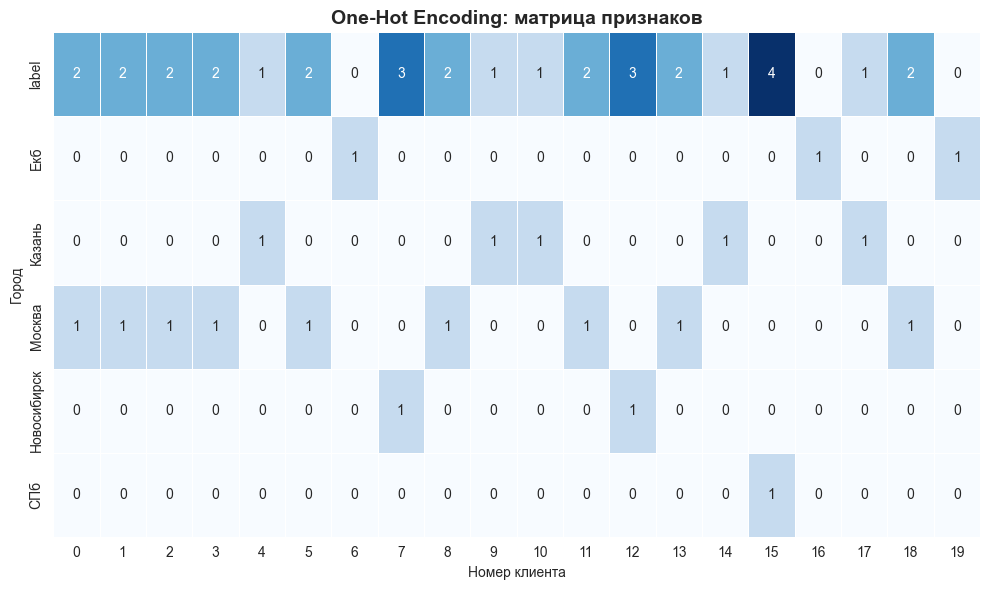

💡 Каждый город — отдельный столбец (0 или 1)


In [23]:
# Визуализация One-Hot Encoding
fig, ax = plt.subplots(figsize=(10, 6))

# Создаём матрицу для heatmap
sample_data = pd.concat([data[['city']], data_ohe[ohe_cols]], axis=1).head(20)
heatmap_data = sample_data[ohe_cols].astype(int).T

sns.heatmap(heatmap_data, cmap='Blues', cbar=False, annot=True, fmt='d', 
            linewidths=0.5, linecolor='white', ax=ax,
            yticklabels=[col.replace('city_', '') for col in ohe_cols])
ax.set_title('One-Hot Encoding: матрица признаков', fontsize=14, fontweight='bold')
ax.set_xlabel('Номер клиента')
ax.set_ylabel('Город')

plt.tight_layout()
plt.show()

print('💡 Каждый город — отдельный столбец (0 или 1)')

## 🎯 Drop First: избегаем мультиколлинеарности

При использовании OHE с линейными моделями нужно удалить один столбец (drop_first=True), чтобы избежать избыточности.

In [24]:
# Сравниваем с drop_first=True и False
data_ohe_full = pd.get_dummies(data, columns=['city'], prefix='city', drop_first=False)
data_ohe_drop = pd.get_dummies(data, columns=['city'], prefix='city', drop_first=True)

print('Сравнение:\n')
print(f'❌ drop_first=False: {len([c for c in data_ohe_full.columns if c.startswith("city_")])} столбцов')
print(f'✅ drop_first=True: {len([c for c in data_ohe_drop.columns if c.startswith("city_")])} столбцов')
print('\n💡 Один столбец избыточен: если все 0 → это пропущенный город')

Сравнение:

❌ drop_first=False: 6 столбцов
✅ drop_first=True: 5 столбцов

💡 Один столбец избыточен: если все 0 → это пропущенный город


## 3️⃣ Ordinal Encoding

**Как работает**: Присваивает числа с учётом порядка категорий

**Когда использовать**:
- ✅ Признаки с естественным порядком (образование, уровень)
- ❌ Номинальные признаки без порядка

In [25]:
# Ordinal Encoding с явным порядком
education_order = ['Школа', 'Бакалавр', 'Магистр', 'PhD']

ord_encoder = OrdinalEncoder(categories=[education_order])
data['education_ordinal'] = ord_encoder.fit_transform(data[['education']])

print('Ordinal Encoding для education:\n')
edu_encoding = pd.DataFrame({
    'Образование': education_order,
    'Код': range(len(education_order))
})
display(edu_encoding)

print('\n✅ Теперь порядок имеет смысл: Школа (0) < Бакалавр (1) < Магистр (2) < PhD (3)')

Ordinal Encoding для education:



,Образование,Код
0,Школа,0
1,Бакалавр,1
2,Магистр,2
3,PhD,3



✅ Теперь порядок имеет смысл: Школа (0) < Бакалавр (1) < Магистр (2) < PhD (3)


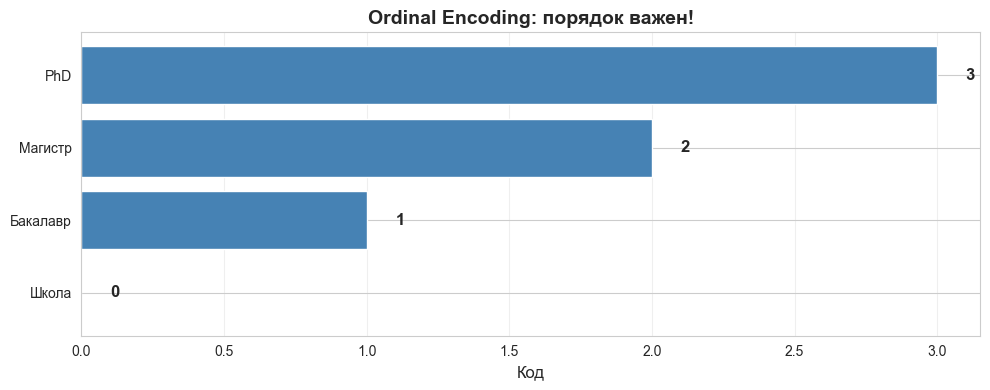

In [26]:
# Визуализация ordinal encoding
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(education_order, range(len(education_order)), color='steelblue', edgecolor='white')
ax.set_xlabel('Код', fontsize=12)
ax.set_title('Ordinal Encoding: порядок важен!', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Добавим значения
for bar, idx in zip(bars, range(len(education_order))):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
            str(idx), va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4️⃣ Target Encoding (Mean Encoding)

**Как работает**: Заменяет категорию средним значением целевой переменной для этой категории

**Когда использовать**:
- ✅ Много категорий (>50)
- ✅ Важные признаки с сильной связью с target
- ⚠️ Требует осторожности (риск переобучения!)

In [27]:
# Target Encoding вручную
# Кодируем город средним значением purchased для этого города

city_target_mean = data.groupby('city')['purchased'].mean()
data['city_target_enc'] = data['city'].map(city_target_mean)

print('Target Encoding для city (средний purchase rate):\n')
target_enc = pd.DataFrame({
    'Город': city_target_mean.index,
    'Средний purchase rate': city_target_mean.values.round(3)
}).sort_values('Средний purchase rate', ascending=False)
display(target_enc)

print('\n💡 Теперь модель видит, в каких городах чаще совершаются покупки!')

Target Encoding для city (средний purchase rate):



,Город,Средний purchase rate
0,Екб,0.545
1,Казань,0.500
3,Новосибирск,0.444
4,СПб,0.429
2,Москва,0.387



💡 Теперь модель видит, в каких городах чаще совершаются покупки!


## 5️⃣ Frequency Encoding

**Как работает**: Заменяет категорию частотой её встречаемости

**Когда использовать**:
- ✅ Когда важна распространённость категории
- ✅ Как дополнительный признак

In [28]:
# Frequency Encoding
city_freq = data['city'].value_counts(normalize=True)
data['city_freq_enc'] = data['city'].map(city_freq)

print('Frequency Encoding для city:\n')
freq_enc = pd.DataFrame({
    'Город': city_freq.index,
    'Частота': city_freq.values.round(3),
    'Процент': (city_freq.values * 100).round(1).astype(str) + '%'
})
display(freq_enc)

Frequency Encoding для city:



,Город,Частота,Процент
0,Москва,0.31,31.0%
1,Казань,0.24,24.0%
2,Екб,0.22,22.0%
3,СПб,0.14,14.0%
4,Новосибирск,0.09,9.0%


## 📊 Сравнение методов кодирования

In [29]:
# Сводная таблица методов
comparison = pd.DataFrame({
    'Метод': ['Label', 'One-Hot', 'Ordinal', 'Target', 'Frequency'],
    'Столбцов': ['1', 'N', '1', '1', '1'],
    'Порядок': ['❌', '❌', '✅', '❌', '❌'],
    'Для target': ['❌', '❌', '❌', '✅', '❌'],
    'Риск переобучения': ['Низкий', 'Низкий', 'Низкий', 'Высокий', 'Низкий'],
    'Лучшее применение': ['Бинарные', 'Номинальные', 'Ординальные', 'Много категорий', 'Доп. признак']
})

comparison.style.set_properties(**{'text-align': 'center'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}])

,Метод,Столбцов,Порядок,Для target,Риск переобучения,Лучшее применение
0,Label,1,❌,❌,Низкий,Бинарные
1,One-Hot,N,❌,❌,Низкий,Номинальные
2,Ordinal,1,✅,❌,Низкий,Ординальные
3,Target,1,❌,✅,Высокий,Много категорий
4,Frequency,1,❌,❌,Низкий,Доп. признак


## 💼 Бизнес-кейс: E-commerce

**Задача**: Предсказать, купит ли клиент в этой сессии

**Категориальные признаки**:
- Источник трафика (organic, paid, social, direct)
- Устройство (mobile, desktop)
- Браузер (Chrome, Safari, Firefox...)
- Город (100+ городов)

**Применённое кодирование**:
| Признак | Метод | Почему |
|---------|-------|--------|
| Устройство | Label | Бинарный признак |
| Источник | One-Hot | Номинальный, мало категорий |
| Город | Target | 100+ городов, сильная связь с покупками |
| Браузер | Frequency | Важна распространённость |

**Результат**:
- Accuracy: 0.72 → 0.84
- ROC-AUC: 0.68 → 0.81
- ROI рекламы: +25%

## 📝 Чек-лист кодирования

- [ ] Определить тип категории (бинарная/номинальная/ординальная)
- [ ] Посчитать количество уникальных значений
- [ ] Выбрать метод по таблице сравнения выше
- [ ] Применить кодирование
- [ ] Проверить, нет ли утечки данных (для Target Encoding)
- [ ] Удалить исходные категориальные столбцы

---

## 🎓 Практическое задание

1. Возьмите датасет с 3+ категориальными признаками
2. Примените 3 разных метода кодирования
3. Обучите простую модель на каждом варианте
4. Сравните метрики

---

## ➡️ Что дальше?

В следующем уроке научимся **масштабировать и нормализовать** признаки — приводить их к единому диапазону для лучшей работы моделей.